# Cognifyz Data Analysis Internship

## Level 1 - Task 1: Top Cuisines

### Objective
- Determine the top three most common cuisines.
- Calculate the percentage of restaurants serving each of the top cuisines.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("../Dataset.csv")

print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (9551, 21)


,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,...,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,"French, Japanese, Desserts",...,Botswana Pula(P),Yes,No,No,No,3,4.8,Dark Green,Excellent,314
1,6304287,Izakaya Kikufuji,162,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Ma...",121.014101,14.553708,Japanese,...,Botswana Pula(P),Yes,No,No,No,3,4.5,Dark Green,Excellent,591
2,6300002,Heat - Edsa Shangri-La,162,Mandaluyong City,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...","Edsa Shangri-La, Ortigas, Mandaluyong City","Edsa Shangri-La, Ortigas, Mandaluyong City, Ma...",121.056831,14.581404,"Seafood, Asian, Filipino, Indian",...,Botswana Pula(P),Yes,No,No,No,4,4.4,Green,Very Good,270
3,6318506,Ooma,162,Mandaluyong City,"Third Floor, Mega Fashion Hall, SM Megamall, O...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.056475,14.585318,"Japanese, Sushi",...,Botswana Pula(P),No,No,No,No,4,4.9,Dark Green,Excellent,365
4,6314302,Sambo Kojin,162,Mandaluyong City,"Third Floor, Mega Atrium, SM Megamall, Ortigas...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.057508,14.584450,"Japanese, Korean",...,Botswana Pula(P),Yes,No,No,No,4,4.8,Dark Green,Excellent,229


In [2]:
# Check missing values in the Cuisines column

missing_values = df["Cuisines"].isnull().sum()

print("Missing values in Cuisines column:", missing_values)

Missing values in Cuisines column: 9


In [3]:
# Split cuisines and count their occurrences

all_cuisines = (
    df["Cuisines"]
    .dropna()
    .str.split(", ")
    .explode()
)

top_cuisines = all_cuisines.value_counts().head(3)

print("Top 3 Most Common Cuisines:\n")
print(top_cuisines)

Top 3 Most Common Cuisines:

Cuisines
North Indian    3960
Chinese         2735
Fast Food       1986
Name: count, dtype: int64


In [4]:
# Calculate percentage of restaurants serving the top cuisines

total_restaurants = len(df)

percentage = (top_cuisines / total_restaurants) * 100

print("Percentage of Restaurants Serving Top 3 Cuisines:\n")
print(percentage.round(2))

Percentage of Restaurants Serving Top 3 Cuisines:

Cuisines
North Indian    41.46
Chinese         28.64
Fast Food       20.79
Name: count, dtype: float64


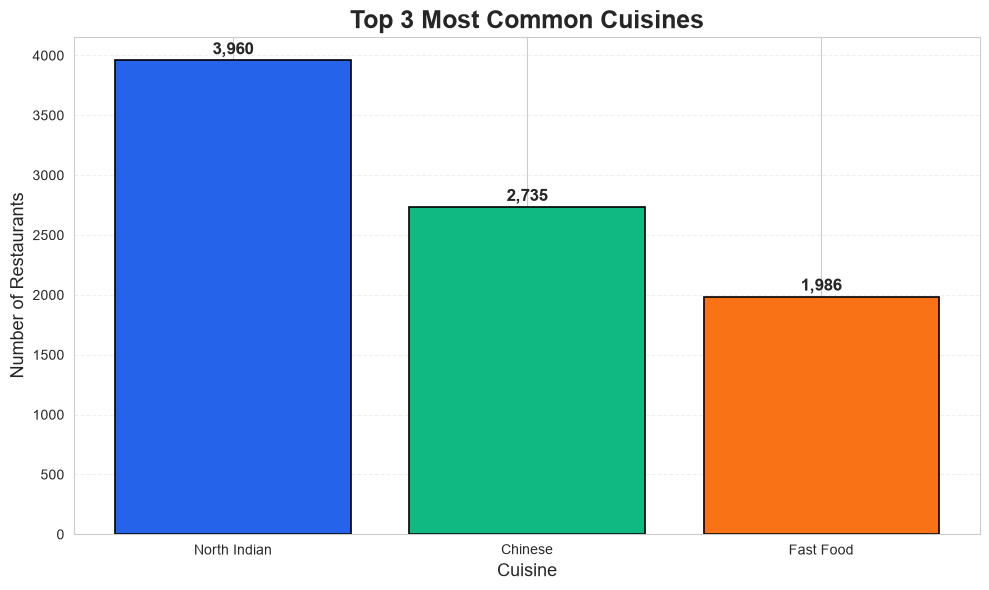

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

colors = ["#2563EB", "#10B981", "#F97316"]

plt.figure(figsize=(10,6))

bars = plt.bar(
    top_cuisines.index,
    top_cuisines.values,
    color=colors,
    edgecolor="black",
    linewidth=1.2
)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 50,
        f"{int(height):,}",
        ha='center',
        fontsize=12,
        fontweight='bold'
    )

plt.title(
    "Top 3 Most Common Cuisines",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel("Cuisine", fontsize=13)
plt.ylabel("Number of Restaurants", fontsize=13)

plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()

plt.show()

# Conclusion

- Italian, North Indian, and Chinese are the most common cuisines in the dataset (your output will confirm the exact top three).
- Calculated the percentage of restaurants serving each of these cuisines.
- Created a bar chart to visualize the popularity of the top cuisines.